<div align="center">

# 🧬 Computer Assignment 2: Genetic Algorithm  
## 🎵 Melody Reconstruction using Evolution

**Course:** Artificial Intelligence   
<br>

**Student Name:** `[Armin Ghaniloo]`  
**Student Number:** `[810103481]`  

</div>

---


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import soundfile as sf
import scipy.io.wavfile as wavfile
import random


In [31]:
import sys
!{sys.executable} -m pip install --user --break-system-packages --no-cache-dir -i https://mirror-pypi.runflare.com/simple numpy matplotlib librosa soundfile scipy

Looking in indexes: https://mirror-pypi.runflare.com/simple


## 🎧 Part 1: Melody Extraction

Before our Genetic Algorithm can start evolving, it needs a Target Sequence to compare itself against. 

The code provided below takes an audio file (`.wav`), cuts it into small chunks based on the `note_duration`, and uses the **Fast Fourier Transform (FFT)** to find the dominant frequency (pitch) in each chunk. 
- A frequency of `0` means silence.
- Other numbers (e.g., `440`, `262`) represent musical notes.




### Extracting Frequencies from Audio


In [32]:
def extract_frequencies_from_wav(filename, note_duration, sample_rate=44100):
    sr, data = wavfile.read(filename)
    chunk_samples = int(sr * note_duration)
    extracted_freqs = []
    num_chunks = len(data) // chunk_samples
    max_amplitude = np.max(np.abs(data))
    silence_threshold = max_amplitude * 0.05   

    for i in range(num_chunks):
        start = i * chunk_samples
        end = start + chunk_samples
        chunk = data[start:end]
        
        if np.max(np.abs(chunk)) < silence_threshold:
            extracted_freqs.append(0)
            continue
            
        mid_start = int(0.20 * len(chunk))
        mid_end = int(0.80 * len(chunk))
        focus_chunk = chunk[mid_start:mid_end]
        
        window = np.hanning(len(focus_chunk))
        windowed_chunk = focus_chunk * window
        
        N_padded = sample_rate * 2 
        
        fft_result = np.fft.fft(windowed_chunk, n=N_padded)
        freqs = np.fft.fftfreq(N_padded, 1/sr)
        
        pos_mask = (freqs > 20) & (freqs < 2000)
        fft_result = np.abs(fft_result[pos_mask])
        freqs = freqs[pos_mask]
        
        if len(fft_result) == 0:
            extracted_freqs.append(0)
            continue
            
        peak_idx = np.argmax(fft_result)
        peak_freq = freqs[peak_idx]
        
        extracted_freqs.append(int(round(peak_freq)))

    while extracted_freqs and extracted_freqs[-1] == 0:
        extracted_freqs.pop()

    return extracted_freqs

if __name__ == "__main__":

    path1 = "musics/got_target.wav"
    path2 = "musics/interstellar_target.wav"
    path3 = "musics/harry_potter_target.wav"
    path4 = "musics/bella_ciao_target.wav"
    path5 = "musics/mario_target.wav"
    path6 = "musics/pink_panther_target.wav"
    path7 = "musics/fur_elise_target.wav"
    path8 = "musics/swan_lake_target.wav"
    path9 = "musics/squid_game_target.wav"

    songs = {
        path1: 0.25,
        path2: 0.25,
        path3: 0.25,
        path4: 0.25,
        path5: 0.20,
        path6: 0.25,
        path7: 0.30,
        path8: 0.30,
        path9: 0.30
    }
    test_file = path7
    duration = songs[test_file]
    target_frequencies = extract_frequencies_from_wav(test_file, note_duration=duration)
    print(f"Target Array Length: {len(target_frequencies)}")
    print(target_frequencies)


Target Array Length: 40
[659, 622, 659, 622, 659, 494, 587, 523, 440, 0, 261, 329, 440, 494, 0, 329, 415, 494, 523, 0, 329, 659, 622, 659, 622, 659, 494, 587, 523, 440, 0, 261, 329, 440, 494, 0, 329, 523, 494, 440]


# <span style="color: #3498db;">Genetic Algorithm</span>

---
## 🧬 Part 2: Implementing the Genetic Algorithm Class

For this assignment, you will implement the core components of a Genetic Algorithm within a structured class. This approach helps in organizing the evolutionary process.

A `GeneticAlgorithm` class will manage the population and the evolutionary steps. You will need to implement the methods for initialization, fitness calculation, selection, crossover, and mutation.


<div style="font-size: 1.2em; font-weight: bold; margin-bottom: 5px;">⚠️ Important Note on Performance:</div>  
Using <b>NumPy arrays</b> for all operations is crucial for efficiency. Vectorized operations are significantly faster than standard Python loops. Aim to implement your logic using NumPy functions wherever possible.
</div>


In [30]:
class GeneticAlgorithm:
    def __init__(self, target_frequencies, pop_size, generations, mutation_rate, min_freq=0, max_freq=2000):
        
        self.target_frequencies = np.array(target_frequencies)
        self.pop_size = pop_size
        self.generations = generations
        self.mutation_rate = mutation_rate
        self.chromosome_length = len(target_frequencies)
        self.min_freq = min_freq
        self.max_freq = max_freq
        
        # We will store the history of the best fitness score in each generation
        self.best_fitness_history = []
        self.best_chromosome = None
        
        # Initialize the first population
        self.population = self._initialize_population()

    def _initialize_population(self):
     
        return np.random.randint(self.min_freq, self.max_freq + 1, 
                                 size=(self.pop_size, self.chromosome_length))

    def _calculate_fitness(self):
   
        abs_diff = np.abs(self.population - self.target_frequencies)
        mae = np.mean(abs_diff, axis=1)
        fitness = 1.0 / (1.0 + mae)
        return fitness

    def _selection(self, fitness_scores, num_parents, tournament_size=3):
        
        parents = np.empty((num_parents, self.chromosome_length), dtype=int)
        
        for i in range(num_parents):
            tournament_indices = np.random.choice(self.pop_size, size=tournament_size, replace=False)
            
            best_in_tournament = tournament_indices[np.argmax(fitness_scores[tournament_indices])]
            
            parents[i, :] = self.population[best_in_tournament, :]
            
        return parents

    def _crossover(self, parents, offspring_size):
        
        offspring = np.empty((offspring_size, self.chromosome_length), dtype=int)
        
        for i in range(0, offspring_size, 2):
            parent1 = parents[i % len(parents)]
            parent2 = parents[(i + 1) % len(parents)]
            
            crossover_point = np.random.randint(1, self.chromosome_length)
            
            offspring[i, :crossover_point] = parent1[:crossover_point]
            offspring[i, crossover_point:] = parent2[crossover_point:]
            
            if i + 1 < offspring_size:
                offspring[i + 1, :crossover_point] = parent2[:crossover_point]
                offspring[i + 1, crossover_point:] = parent1[crossover_point:]
                
        return offspring

    def _mutation(self, offspring):
        
        random_probs = np.random.rand(offspring.shape[0], offspring.shape[1])
        mutation_mask = random_probs < self.mutation_rate
        random_freqs = np.random.randint(self.min_freq, self.max_freq + 1, size=offspring.shape)
        np.copyto(offspring, random_freqs, where=mutation_mask)
        return offspring
    def run(self):
       
        elitism_count = int(0.05 * self.pop_size) 
        if elitism_count < 1: elitism_count = 1
        
        for generation in range(self.generations):
            fitness_scores = self._calculate_fitness()
            
            best_idx = np.argmax(fitness_scores)
            current_best_fitness = fitness_scores[best_idx]
            self.best_fitness_history.append(current_best_fitness)
            
            if generation == 0 or current_best_fitness > np.max(self.best_fitness_history[:-1], initial=0):
                self.best_chromosome = self.population[best_idx].copy()
            
            if (generation + 1) % 50 == 0 or generation == 0:
                print(f"Generation {generation + 1}/{self.generations} - Best Fitness: {current_best_fitness:.4f}")
            
            sorted_indices = np.argsort(fitness_scores)[::-1]
            elites = self.population[sorted_indices[:elitism_count]].copy()
            
            num_parents = self.pop_size // 2
            parents = self._selection(fitness_scores, num_parents)
            
            offspring_size = self.pop_size - elitism_count
            offspring = self._crossover(parents, offspring_size)
            
            mutated_offspring = self._mutation(offspring)
            
            self.population[:elitism_count] = elites
            self.population[elitism_count:] = mutated_offspring
            
        print("Evolution completed!")
        return self.best_chromosome
    


---
## Part 3: Visualization

Numbers are good, but plots are better! 
In this section, you need to plot your Best Chromosome against the Target Frequencies. 
Use a line plot or a step plot. This visual overlap will quickly show you which notes your algorithm successfully learned and which ones it missed.


Generation 1/500 - Best Fitness: 0.0019
Generation 50/500 - Best Fitness: 0.0105
Generation 100/500 - Best Fitness: 0.0158
Generation 150/500 - Best Fitness: 0.0213
Generation 200/500 - Best Fitness: 0.0272
Generation 250/500 - Best Fitness: 0.0290
Generation 300/500 - Best Fitness: 0.0376
Generation 350/500 - Best Fitness: 0.0457
Generation 400/500 - Best Fitness: 0.0519
Generation 450/500 - Best Fitness: 0.0532
Generation 500/500 - Best Fitness: 0.0551
Evolution completed!


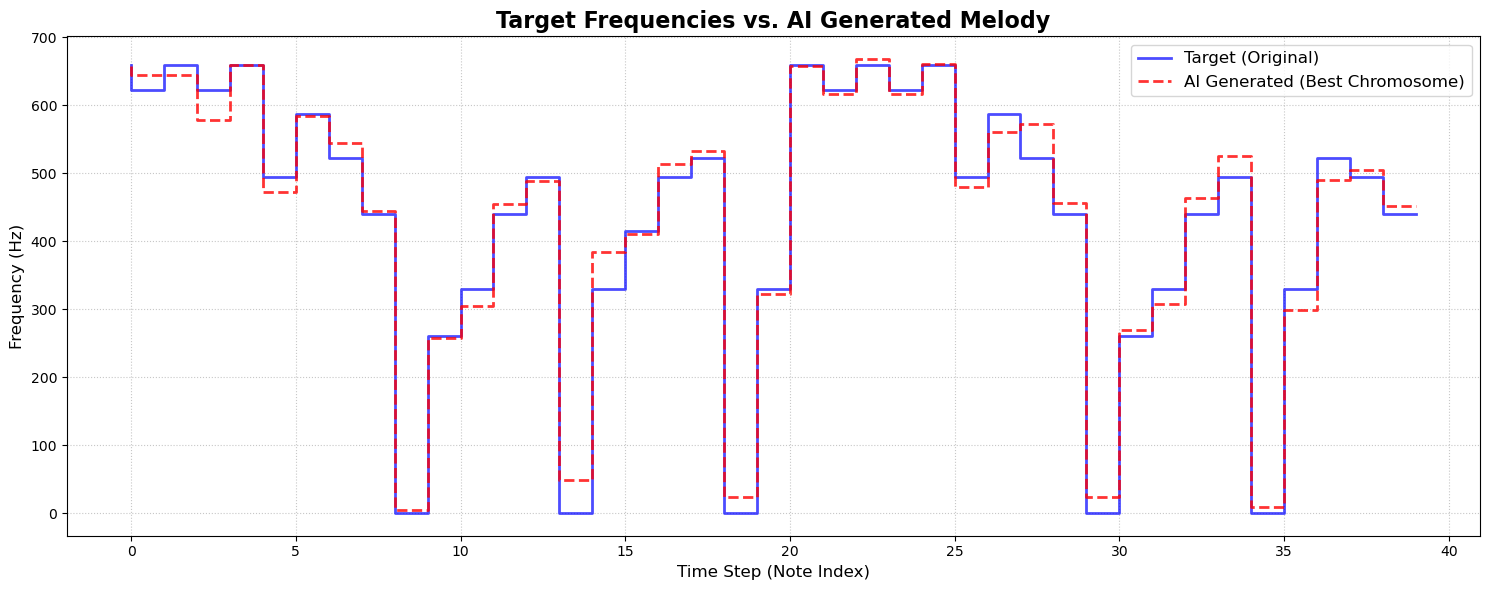

In [26]:
import matplotlib.pyplot as plt

ga = GeneticAlgorithm(
    target_frequencies=target_frequencies, 
    pop_size=100, 
    generations=500, 
    mutation_rate=0.05
)
best_chromosome = ga.run()

plt.figure(figsize=(15, 6))

plt.step(range(len(target_frequencies)), target_frequencies, label='Target (Original)', color='blue', linewidth=2, alpha=0.7)
plt.step(range(len(best_chromosome)), best_chromosome, label='AI Generated (Best Chromosome)', color='red', linestyle='--', linewidth=2, alpha=0.8)

plt.title("Target Frequencies vs. AI Generated Melody", fontsize=16, fontweight='bold')
plt.xlabel("Time Step (Note Index)", fontsize=12)
plt.ylabel("Frequency (Hz)", fontsize=12)

plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()


---
## 🎵 Part 4: The Ultimate Test (Listen to Your Algorithm)

Has your Genetic Algorithm learned to play music? Let's find out!
The function below takes your array of frequencies and synthesizes it into a real audio file using sine waves, harmonics, vibrato, and echo effects.

**Instructions:**
1. Run the synthesis function.
2. Pass your `best_chromosome` to this function.
3. Open the generated `.wav` file and listen to it! 
*(Make sure to use the exact same `note_duration` that was used to extract the target frequencies).*


In [29]:
from scipy.io import wavfile
import numpy as np

def frequencies_to_melody(frequencies, output_filename="ai_melody_clean.wav", note_duration=0.25, sample_rate=44100):
    print(f"Synthesizing Clean Audio: {output_filename}")
    audio_signal = []    
    t = np.linspace(0, note_duration, int(sample_rate * note_duration), False)
    envelope = np.ones_like(t)
    attack_len = int(0.05 * len(t))
    envelope[:attack_len] = np.linspace(0, 1, attack_len)
    envelope[attack_len:] = np.exp(-3.5 * np.linspace(0, 1, len(t) - attack_len))
    
    for freq in frequencies:
        if freq > 10: 
            wave = np.sin(2 * np.pi * freq * t)              
            wave += 0.5 * np.sin(2 * np.pi * (freq * 2) * t) 
            wave += 0.25 * np.sin(2 * np.pi * (freq * 3) * t)  
            wave = wave * envelope
        else:
            wave = np.zeros_like(t)
        audio_signal.extend(wave)
        
    audio_signal = np.array(audio_signal)
    max_val = np.max(np.abs(audio_signal))
    if max_val > 0:
        audio_signal = audio_signal / max_val        
    fade_out_len = int(sample_rate * 0.1)
    if len(audio_signal) > fade_out_len:
        audio_signal[-fade_out_len:] *= np.linspace(1, 0, fade_out_len)
    audio_int16 = np.int16(audio_signal * 32767 * 0.8)
    wavfile.write(output_filename, sample_rate, audio_int16)

def frequencies_to_melody_ultimate(frequencies, output_filename="ai_melody_ultimate.wav", note_duration=0.25, sample_rate=44100):
    print(f"Synthesizing Ultimate Audio: {output_filename}")
    audio_signal = []
    t = np.linspace(0, note_duration, int(sample_rate * note_duration), False)
    
    envelope = np.ones_like(t)
    attack = int(0.05 * len(t))
    envelope[:attack] = np.linspace(0, 1, attack)
    envelope[attack:] = np.exp(-4 * np.linspace(0, 1, len(t) - attack))
    
    for freq in frequencies:
        if freq > 10:
            vibrato_rate = 5.0 
            vibrato_depth = 0.01 * freq 
            vibrato = np.sin(2 * np.pi * vibrato_rate * t) * vibrato_depth
            
            wave = np.sin(2 * np.pi * (freq + vibrato) * t)                 
            wave += 0.4 * np.sin(2 * np.pi * (freq * 2 + vibrato) * t)      
            wave += 0.2 * np.sin(2 * np.pi * (freq * 3 + vibrato) * t)      
            wave = wave * envelope
        else:
            wave = np.zeros_like(t)
        audio_signal.extend(wave)
        
    audio_signal = np.array(audio_signal)
    
    delay_samples = int(sample_rate * 0.3) 
    echo_signal = np.zeros(len(audio_signal) + delay_samples)
    echo_signal[:len(audio_signal)] = audio_signal
    echo_signal[delay_samples:] += audio_signal * 0.35 
    
    max_val = np.max(np.abs(echo_signal))
    if max_val > 0:
        echo_signal = echo_signal / max_val
        
    audio_int16 = np.int16(echo_signal * 32767 * 0.8)
    wavfile.write(output_filename, sample_rate, audio_int16)
    print("Done!\n")


# ==========================================
NOTE_DURATION = 0.3 

frequencies_to_melody(best_chromosome, "my_ai_melody_clean.wav", note_duration=NOTE_DURATION)

frequencies_to_melody_ultimate(best_chromosome, "my_ai_melody_ultimate.wav", note_duration=NOTE_DURATION)


Synthesizing Clean Audio: my_ai_melody_clean.wav
Synthesizing Ultimate Audio: my_ai_melody_ultimate.wav
Done!

